
# Ejemplo Redes neuronales convolucionales

Repositorio del cuál se ha extraído el notebook [link](https://github.com/jorditorresBCN/python-deep-learning)

Libro asociado **Python Deep Learning** Introducción práctica con Keras y TensorFlow 2. Jordi Torres. [link](https://www.marcombo.com/python-deep-learning-9788426728289/)


In [1]:
# %tensorflow_version 2.x
import tensorflow as tf
from tensorflow import keras

import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)


I0000 00:00:1776759051.603202   22873 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776759051.640840   22873 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776759052.652027   22873 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


2.21.0


## Datos digits MNIST

1. Capa Conv2DOutput Shape: (None, 24, 24, 32)None: Representa el tamaño del "batch" (lote de imágenes). TensorFlow lo deja en None porque el modelo puede recibir cualquier cantidad de imágenes al mismo tiempo (ej. 1, 32 o 64 imágenes de golpe).24, 24: Aquí es donde aplicas tu lógica de "empiezo con 28x28 y pasa a 24x24". Esto ocurre porque al deslizar un filtro de 5x5 sobre una imagen de 28x28 sin agregar bordes artificiales (padding), el filtro "choca" con los bordes antes. La fórmula matemática es: $Tamaño_{salida} = Tamaño_{entrada} - Tamaño_{filtro} + 1$. Por lo tanto: $28 - 5 + 1 = 24$.32: Es el número de filtros (patrones) que le pediste a la capa que buscara.Param # (Parámetros a entrenar): 832¿De dónde sale este número? Son los "pesos" que la red neuronal tiene que aprender.Cada filtro es de 5x5, lo que equivale a $5 \times 5 = 25$ píxeles.Como tu imagen de entrada tiene 1 canal de profundidad, el filtro tiene $25 \times 1 = 25$ pesos.A cada filtro se le suma 1 valor extra llamado "sesgo" (bias). Entonces, cada filtro tiene $25 + 1 = 26$ parámetros.Como tienes 32 filtros en total: $26 \times 32 = 832$ parámetros.2. Capa MaxPooling2DOutput Shape: (None, 12, 12, 32)12, 12: Tu filtro de pooling es de (2, 2). Lo que hace es dividir el tamaño de la imagen a la mitad. Pasa de 24x24 a 12x12 ($24 / 2 = 12$). Aquí tu intuición es 100% correcta cuando dices "cada 4 son 1": toma un cuadrante de 2x2 (4 píxeles) y se queda solo con el valor más alto.32: El número de canales se mantiene igual. El pooling solo encoge el alto y ancho, no toca la cantidad de filtros.Param # (Parámetros a entrenar): 0El valor es 0 porque la capa de MaxPooling no aprende nada. No tiene pesos ni sesgos matemáticos; simplemente es una operación fija que escoge el número más grande de un grupo de píxeles para reducir el tamaño computacional.Aclaraciones sobre tus comentarios (Mitos y realidades)Has dejado notas muy interesantes en el código. Vamos a confirmarlas o corregirlas suavemente:"el uno se usa para las colores par aindeitidciar colores rgb"Corrección: Es al revés. El 1 significa que es una imagen en escala de grises (blanco y negro, un solo canal). Si fueran imágenes a color RGB, usarías un 3 (por los canales Red, Green, Blue)."para convuluciones funciones siempre relu"Realidad: Casi siempre, sí. relu es el estándar de la industria para las capas ocultas porque es rápida y evita problemas matemáticos durante el entrenamiento. Sin embargo, no es estrictamente la única (a veces se usa LeakyReLU o ELU), pero relu es la mejor opción por defecto."EN CADA CAPA Es normal buscar != patrones -> 32. para filtros deciudidir el numero de depende al complejidad de la img"Realidad: ¡Exactamente! Mientras más profunda es la red, más filtros se suelen poner (por ejemplo, pasar de 32 a 64 y luego a 128) porque la red empieza buscando patrones simples (líneas, bordes) y luego los combina para buscar cosas complejas (ojos, caras, ruedas de coches)."especificar un numero computiconal en base ddos 2,4,6,8,10"Corrección: No son números pares, son potencias de 2. Es decir: 16, 32, 64, 128, 256, 512. Se hace así porque las arquitecturas de las tarjetas gráficas (GPUs) procesan la información de manera mucho más eficiente cuando los bloques de memoria son potencias de 2.

In [2]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D

model = Sequential()
model.add(Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1)))
# 28,28, 1 -> el uno se usa para las colores par aindeitidciar colores rgb
# para convuluciones funciones siempre relu
# 5,5  ES LO DEL FILTER
# EN CADA CAPA Es normal buscar != patrones -> 32
# apra filtros deciudidir el numero de depende al complejidad de la img no es lo mismo un cuadrado que una cara 
# especificar un numero computiconal en base ddos 2,4,6,8,10
model.add(MaxPooling2D((2, 2)))
model.summary()
# cada 4 son 1

# empiezo con 28X28, y pasa a la capa de pooling 24x24 al mover los filtros 5 a 5 



/media/a22nicolesdc/DIURNOEXTRA/miniconda3/envs/ML/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1776759053.693900   22873 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 832 (3.25 KB)

 Trainable params: 832 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

. El tamaño de salida de la Convolución (Output Shape)Asumiendo que usas la configuración por defecto de Keras (padding='valid' y strides=1), la regla de oro es:

$Salida = Entrada - Filtro + 1$Ejemplo rápido: Tienes una imagen de $28 \times 28$ y aplicas un filtro de $5 \times 5$.

Cálculo: $28 - 5 + 1 = 24$.Resultado: Tu nueva imagen es de $24 \times 24$.(Nota pro: Si le dices a la capa padding='same', el tamaño de salida será exactamente igual al de entrada, así que no hay que calcular nada).2. Los parámetros a entrenar de la Convolución (Param #)Esta es la fórmula que más suelen preguntar. Para calcular los "pesos" que la red debe aprender:$Parametros = ((Ancho\_Filtro \times Alto\_Filtro \times Canales\_Entrada) + 1) \times Numero\_Filtros$Ejemplo rápido: Tu filtro es de $5 \times 5$, la imagen previa tiene $1$ canal (gris), y quieres $32$ filtros en esta capa.Cálculo: * Tamaño del filtro: $5 \times 5 = 25$Multiplicas por canales previos: $25 \times 1 = 25$Sumas el "sesgo" (bias): $25 + 1 = 26$Multiplicas por tus filtros: $26 \times 32 = 832$(Nota pro: Si esta capa estuviera después de otra convolución que sacó 32 filtros, los canales de entrada serían 32, no 1).3. El tamaño de salida del Pooling (MaxPooling2D)El pooling casi siempre usa un tamaño de $(2, 2)$ y no se solapa.$Salida = Entrada \div Tamaño\_Pool$Ejemplo rápido: Vienes de un tamaño $24 \times 24$ y tu pool es de $2 \times 2$.Cálculo: $24 \div 2 = 12$.Resultado: Tu nueva imagen es de $12 \times 12$.¿Y los parámetros? SIEMPRE son 0.

In [3]:

model = Sequential()
model.add(Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (5, 5), activation='relu'))
model.add(MaxPooling2D((2, 2))) 
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,096 (203.50 KB)

 Trainable params: 52,096 (203.50 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten

model.add(Flatten())
model.add(Dense(10, activation='softmax'))

In [5]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,346 (243.54 KB)

 Trainable params: 62,346 (243.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
from keras.utils import to_categorical

mnist = tf.keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print (train_images.shape)
print (train_labels.shape)
# reshape lo hacemos pq es para poder meterlo en la capa de convutional 
train_images = train_images.reshape((60000, 28, 28, 1))
#indicar el tipo  y se divide -> normalizar de forma manualmente
train_images = train_images.astype('float32') / 255

test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype('float32') / 255

#resultado si es uno 2 o cero , el resultado es un numero
# el resultado de la mia red nneurnall 

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

# la red neuronal saca un array de 10mposiciones en esye caso llenas de 0 y donde solo hay uno es donde
# el valor que es que cree ees 
# [0,1,0,0,0,0]-> 2 
#  port eso le mande de (60000) a (60000,10)
print (train_images.shape)
print (train_labels.shape)


(60000, 28, 28)
(60000,)
(60000, 28, 28, 1)
(60000, 10)


In [7]:

model.compile(loss='categorical_crossentropy',
            optimizer='sgd', # para calcular los pesos con una formula matematica
            metrics=['accuracy'])

model.fit(train_images, train_labels,
        batch_size=100, # 
        epochs=5,
        verbose=1)

test_loss, test_acc = model.evaluate(test_images, test_labels)

print('Test accuracy:', test_acc)

Epoch 1/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7594 - loss: 0.8986
Epoch 2/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9205 - loss: 0.2696
Epoch 3/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9446 - loss: 0.1922
Epoch 4/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9556 - loss: 0.1522
Epoch 5/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9628 - loss: 0.1288
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9702 - loss: 0.1034
Test accuracy: 0.9702000021934509


## Datos Fashion-MNIST

In [8]:
fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 7s 2us/step


In [9]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [10]:
train_images = train_images.reshape((60000, 28, 28, 1))
train_images = train_images.astype('float32') / 255

test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype('float32') / 255

Modelo 1: modelo de base basado en el mismo modelo que el usado para el conjunto datos digits MNIST 

In [11]:

model = Sequential()
model.add(Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (5, 5), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(10, activation='softmax'))

In [12]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,346 (243.54 KB)

 Trainable params: 62,346 (243.54 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_images, train_labels, epochs=5)
test_loss, test_acc = model.evaluate(test_images,  test_labels)
print('Test accuracy:', test_acc)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6981 - loss: 0.8472
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8142 - loss: 0.5199
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8407 - loss: 0.4509
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8550 - loss: 0.4142
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8626 - loss: 0.3892
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8545 - loss: 0.4051
Test accuracy: 0.8544999957084656


In [14]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [15]:
def plot_image(i, predictions_array, true_label, img):
  predictions_array, true_label, img = predictions_array, true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)    

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array, true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#00FF00")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('black')

Volvemos las imagenes a formato original para hacer el plot

In [16]:
train_images = train_images.reshape((60000, 28, 28))
test_images = test_images.reshape((10000, 28, 28))

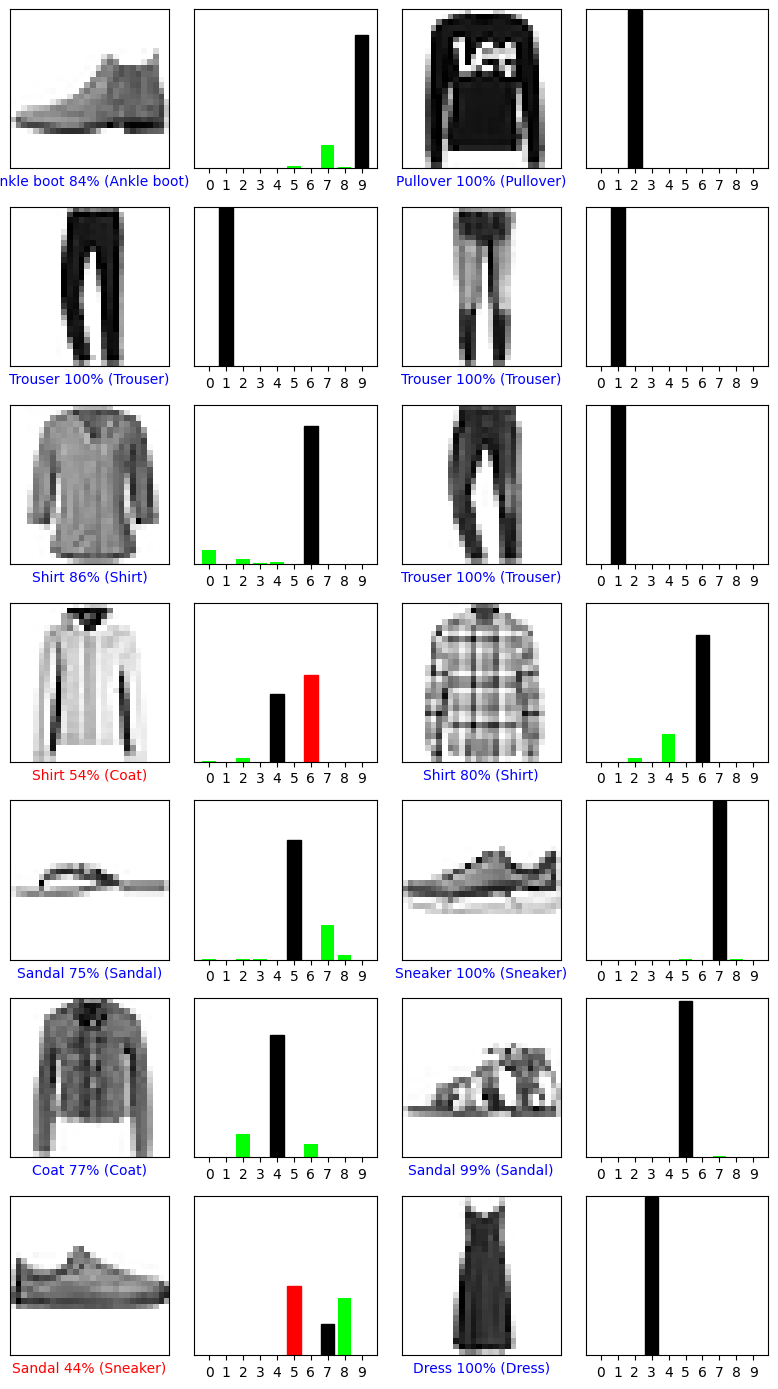

In [17]:
num_rows = 7
num_cols = 2
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions[i], test_labels, test_images)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)     
  plot_value_array(i, predictions[i], test_labels)
plt.tight_layout()
plt.show()



In [18]:
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))


Modelo 2: Duplicando las neuronas de modelo base y añadiendo una capa densa de 64 neuronas

In [19]:

model = Sequential()

model.add(Conv2D(64, (7, 7), activation="relu", padding="same", input_shape=(28, 28, 1)))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
model.add(MaxPooling2D(2, 2))
model.add(Flatten())
model.add(Dense(64, activation="relu"))
model.add(Dense(10, activation="softmax"))



In [20]:

model.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_images, train_labels, epochs=5)

test_loss, test_acc = model.evaluate(test_images,  test_labels)
print('\nTest accuracy:', test_acc)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.7081 - loss: 0.8005
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.8130 - loss: 0.5148
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.8447 - loss: 0.4359
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.8590 - loss: 0.3944
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.8676 - loss: 0.3667
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8687 - loss: 0.3741

Test accuracy: 0.8687000274658203


Modelo 3: modelo 3 cambiando al optimizador 'adam'

In [21]:
model = Sequential()

model.add(Conv2D(64, (7, 7), activation="relu", padding="same", input_shape=(28, 28, 1)))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
model.add(MaxPooling2D(2, 2))
model.add(Flatten())
model.add(Dense(64, activation="relu"))
model.add(Dense(10, activation="softmax"))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_images, train_labels, epochs=5)

test_loss, test_acc = model.evaluate(test_images,  test_labels)
print('\nTest accuracy:', test_acc)

/media/a22nicolesdc/DIURNOEXTRA/miniconda3/envs/ML/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.8536 - loss: 0.4072
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9016 - loss: 0.2691
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9166 - loss: 0.2278
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9261 - loss: 0.1975
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9359 - loss: 0.1712
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9157 - loss: 0.2439

Test accuracy: 0.9157000184059143


Modelo 4: Buscando un modelo más complejo que usa capas BathNormalization y Dropout

In [22]:
from tensorflow.keras.layers import Dropout, BatchNormalization
# drop out, descartar desactivar , en una capa antes de entrar los datos desactiva una parte de las neurtonas, el 25% se desactiva
# apr que vale que se desactive las neuronas, evitar el overfitting -> las otras tiene que ponerse las filas 
# 

def make_model():
  model = Sequential()
  model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', strides=1, padding='same', input_shape=(28,28,1)))
  model.add(BatchNormalization())

  model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', strides=1, padding='same'))
  model.add(BatchNormalization())
  model.add(Dropout(0.25))

  model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', strides=1, padding='same'))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Dropout(0.25))
    
  model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', strides=1, padding='same'))
  model.add(BatchNormalization())
  model.add(Dropout(0.25))

  model.add(Flatten())
  model.add(Dense(512, activation='relu'))
  model.add(BatchNormalization())
  model.add(Dropout(0.5))
  model.add(Dense(128, activation='relu'))
  model.add(BatchNormalization())
  model.add(Dropout(0.5))
  model.add(Dense(10, activation='softmax'))
  return model



In [23]:
model = make_model()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_images, train_labels, epochs=5)

test_loss, test_acc = model.evaluate(test_images,  test_labels)
print('\nTest accuracy:', test_acc)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 235s 124ms/step - accuracy: 0.8325 - loss: 0.4866
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 232s 123ms/step - accuracy: 0.8895 - loss: 0.3159
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 231s 123ms/step - accuracy: 0.9042 - loss: 0.2725
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 227s 121ms/step - accuracy: 0.9122 - loss: 0.2474
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 209s 112ms/step - accuracy: 0.9218 - loss: 0.2213
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9275 - loss: 0.2056

Test accuracy: 0.9275000095367432


Modelo 5: Modelo anterior añadiendo más epochs (10 epochs)

In [ ]:

model = make_model()


model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_images, train_labels, epochs=10)
test_loss, test_acc = model.evaluate(test_images,  test_labels)

print('\nTest accuracy:', test_acc)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 249s 132ms/step - accuracy: 0.8284 - loss: 0.4942
Epoch 2/10
 452/1875 ━━━━━━━━━━━━━━━━━━━━ 3:12 135ms/step - accuracy: 0.8812 - loss: 0.3294

Modelo 6: Modelo anterior añadiendo más epochs (30 epochs)

In [ ]:

model = make_model()

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_images, train_labels, epochs=30)
test_loss, test_acc = model.evaluate(test_images,  test_labels)

print('\nTest accuracy:', test_acc)

Train on 60000 samples
Epoch 1/30
60000/60000 [==============================] - 14s 226us/sample - loss: 0.5218 - accuracy: 0.8189
Epoch 2/30
60000/60000 [==============================] - 13s 213us/sample - loss: 0.3229 - accuracy: 0.8865
Epoch 3/30
60000/60000 [==============================] - 13s 212us/sample - loss: 0.2865 - accuracy: 0.8982
Epoch 4/30
60000/60000 [==============================] - 13s 213us/sample - loss: 0.2493 - accuracy: 0.9110
Epoch 5/30
60000/60000 [==============================] - 13s 216us/sample - loss: 0.2243 - accuracy: 0.9214
Epoch 6/30
60000/60000 [==============================] - 13s 213us/sample - loss: 0.2036 - accuracy: 0.9283
Epoch 7/30
60000/60000 [==============================] - 13s 211us/sample - loss: 0.1881 - accuracy: 0.9330
Epoch 8/30
60000/60000 [==============================] - 13s 212us/sample - loss: 0.1695 - accuracy: 0.9391
Epoch 9/30
60000/60000 [==============================] - 13s 212us/sample - loss: 0.1597 - accuracy: 0.9

Modelo 7: Modelo anterior añadiendo más epochs (30 epochs) y diferentes hiperparámetros al optimizador Adam

In [ ]:
model = make_model()

optimizer = tf.keras.optimizers.Adam (lr=0.001)

model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

reduce_lr = tf.keras.callbacks.LearningRateScheduler(lambda x: 1e-3 * 0.9 ** x)

model.fit(train_images, train_labels, epochs=30, callbacks=[reduce_lr])

test_loss, test_acc = model.evaluate(test_images,  test_labels)
print('\nTest accuracy:', test_acc)

Train on 60000 samples
Epoch 1/30
60000/60000 [==============================] - 14s 228us/sample - loss: 0.5048 - accuracy: 0.8254
Epoch 2/30
60000/60000 [==============================] - 13s 210us/sample - loss: 0.3187 - accuracy: 0.8865
Epoch 3/30
60000/60000 [==============================] - 13s 212us/sample - loss: 0.2693 - accuracy: 0.9048
Epoch 4/30
60000/60000 [==============================] - 13s 211us/sample - loss: 0.2380 - accuracy: 0.9158
Epoch 5/30
60000/60000 [==============================] - 13s 211us/sample - loss: 0.2110 - accuracy: 0.9270
Epoch 6/30
60000/60000 [==============================] - 13s 213us/sample - loss: 0.1849 - accuracy: 0.9345
Epoch 7/30
60000/60000 [==============================] - 13s 210us/sample - loss: 0.1672 - accuracy: 0.9411
Epoch 8/30
60000/60000 [==============================] - 13s 211us/sample - loss: 0.1503 - accuracy: 0.9476
Epoch 9/30
60000/60000 [==============================] - 13s 210us/sample - loss: 0.1367 - accuracy: 0.9

Visualización de las predicciones del modelo 7

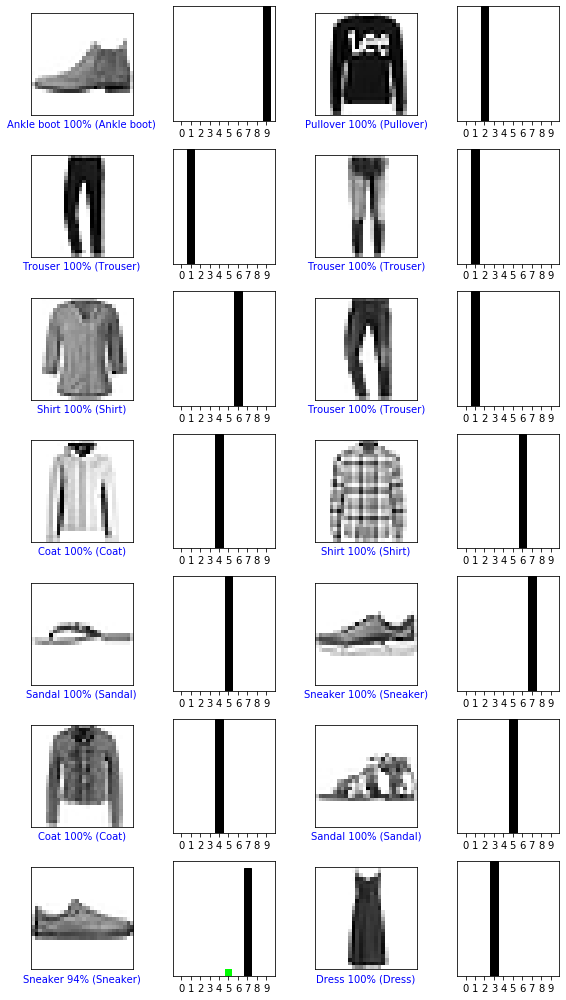

In [ ]:

predictions = model.predict(test_images)

train_images = train_images.reshape((60000, 28, 28))
test_images = test_images.reshape((10000, 28, 28))


num_rows = 7
num_cols = 2
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions[i], test_labels, test_images)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)     
  plot_value_array(i, predictions[i], test_labels)
plt.tight_layout()
plt.show()